# 05 -- Potencjal produkcji energii

Ten notebook obejmuje:

1. **Parametry instalowane** -- gestosc, przyspieszenie, spad, sprawnosci
2. **Model spadu** -- zaleznosc spadu netto od przeplywu (H = f(Q))
3. **Punkt projektowy** -- wybor dnia instalacyjnego na krzywej uporzadkowanej
4. **Obliczenie mocy i energii** -- P(t) = rho * g * Qwpp(t) * H(t) * eta
5. **Ograniczenia eksploatacyjne** -- Qmin, Hmin
6. **Optymalizacja punktu projektowego** -- przeglad dni instalacyjnych
7. **Analiza ekonomiczna** -- koszty, przychod, ROI

Dane wejsciowe: sredni rok uporzadkowany z notebooka 04.

---

## Konfiguracja

### Modul `src/watershed.py` -- nowy modul

**Prompt do LLM tworzacy ten modul:**
> *"Stworz modul src/watershed.py do obslugi zlewnii:
> 1. `load_gauges()` -- wczytaj dane wodowskazow IMGW z data/imgw_gauges.json
> 2. `find_gauge(station_id)` -- znajdz wodowskaz po ID
> 3. `get_catchment_area(lat, lng)` -- pobierz powierzchnie zlewni z cache
>    (data/catchment_areas.json) lub oblicz uzywajac delineatora MERIT
> 4. `get_station_area(station_id)` -- pobierz powierzchnie zlewni dla wodowskazu
> 5. `interpolate_area(A_up, A_down, fraction)` -- interpolacja pow. zlewni
>
> Cache (data/catchment_areas.json) pozwala na prace offline -- wystarczy raz
> obliczyc powierzchnie i zapisac wyniki."*

### Modul `src/hydrology.py` -- istniejace funkcje

**Uzyte funkcje:** average_sorted_year, flow_duration_curve, characteristic_flows,
filter_incomplete_years, transfer_flow_between

**Prompt do LLM:**
> *"Napisz kod konfiguracji notebooka: zaladuj modul src/imgw_data (load_processed) i src/hydrology
> (average_sorted_year, flow_duration_curve, characteristic_flows, filter_incomplete_years,
> transfer_flow_between)."*

**Uzyte moduly/funkcje:** `src.imgw_data`: load_processed; `src.hydrology`: average_sorted_year, flow_duration_curve, characteristic_flows, filter_incomplete_years, transfer_flow_between

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.imgw_data import load_processed
from src.hydrology import (
    average_sorted_year,
    flow_duration_curve,
    characteristic_flows,
    filter_incomplete_years,
    transfer_flow_between,
)
from src.watershed import get_station_area, find_gauge, interpolate_area, get_catchment_area

pd.set_option('display.max_columns', 15)
print('Moduly zaladowane.')

Moduly zaladowane.


**Prompt do LLM:**
> *"Napisz kod ktory: (1) wczyta dane hydrologiczne, (2) zidentyfikuje stacje
> upstream i downstream na Odrze (Brzeg Dolny = upstream, Malczyce = downstream),
> (3) pobierze powierzchnie zlewni z modulu watershed (z cache lub delineatora),
> (4) obliczy powierzchnie zlewni dla lokalizacji MEW (punkt miedzy stacjami).
> Wyswietl informacje o stacjach i zlewniach."*

**Uzyte moduly/funkcje:** `src.imgw_data.load_processed()`, `src.watershed.get_station_area()`, `src.watershed.find_gauge()`, `src.watershed.get_catchment_area()`

In [2]:
# Wczytaj dane (oczyszczone w notebooku 02)
df = load_processed('../data/processed/daily_hydro_clean.parquet')

# Stacje na Odrze (Brzeg Dolny jest upstream, Malczyce downstream)
STATION_UP = '151160170'    # Brzeg Dolny (upstream, mniejsza zlewnia)
STATION_DOWN = '151160150'  # Malczyce (downstream, wieksza zlewnia)

# Powierzchnie zlewni [km2] -- z cache (obliczone delineatorem MERIT)
A_UP = get_station_area(STATION_UP)
A_DOWN = get_station_area(STATION_DOWN)

# Lokalizacja MEW -- punkt miedzy wodowskazami
gauge_up = find_gauge(STATION_UP)
gauge_down = find_gauge(STATION_DOWN)
lat_mew = (gauge_up['lat'] + gauge_down['lat']) / 2
lng_mew = (gauge_up['lng'] + gauge_down['lng']) / 2
A_TARGET = get_catchment_area(lat_mew, lng_mew, label='MEW')

for sid, label in [(STATION_UP, 'upstream'), (STATION_DOWN, 'downstream')]:
    g = find_gauge(sid)
    row = df[df['station_id'] == sid].iloc[0]
    n = len(df[df['station_id'] == sid])
    area = get_station_area(sid)
    print(f'{g["name"]} ({label}): {row["station_name"]} na {row["river_name"]}, A={area:.0f} km2, {n} dni')

print(f'\nLokalizacja MEW: ({lat_mew:.4f}, {lng_mew:.4f}), A = {A_TARGET:.0f} km2')
print(f'  (miedzy {gauge_up["name"]} a {gauge_down["name"]})')

Brzeg Dolny (upstream): BRZEG DOLNY na Odra (1), A=26495 km2, 15705 dni
Malczyce (downstream): MALCZYCE na Odra (1), A=26860 km2, 15705 dni

Lokalizacja MEW: (51.2433, 16.6097), A = 26545 km2
  (miedzy Brzeg Dolny a Malczyce)


---
## Krok 1: Powierzchnie zlewni i interpolacja przeplywu

### 1a. Powierzchnie zlewni

Powierzchnie zlewni sa potrzebne do interpolacji przeplywu miedzy wodowskazami.
Obliczane sa delineatorem MERIT (na bazie globalnych danych hydrologicznych)
i zapisywane w cache (`data/catchment_areas.json`).

**Jesli cache jest pusty:**
- modul `src/watershed.py` sprobuje uruchomic delineator automatycznie
- alternatywnie: dodaj wpis recznie do `data/catchment_areas.json`

### 1b. Interpolacja przeplywu

Lokalizacja MEW lezy miedzy dwoma wodowskazami (Brzeg Dolny i Malczyce).
Uzywamy **metody interpolacyjnej** -- interpolacja potegowa wazona powierzchnia zlewni:

$$n(t) = \frac{\ln Q_{down}(t) - \ln Q_{up}(t)}{\ln A_{down} - \ln A_{up}}$$

$$Q_{MEW}(t) = Q_{up}(t) \cdot \left(\frac{A_{MEW}}{A_{up}}\right)^{n(t)}$$

Wykladnik $n$ obliczany jest dla kazdego dnia z przeplywow na obu wodowskazach.

**Prompt do LLM:**
> *"Napisz kod ktory: (1) polaczy dane z dwoch stacji (Malczyce i Brzeg Dolny) po dacie,
> (2) dla kazdego dnia obliczy wykladnik n = ln(Q_down/Q_up) / ln(A_down/A_up),
> (3) obliczy przeplyw w lokalizacji MEW: Q_mew = Q_up * (A_mew/A_up)^n,
> (4) utworzy DataFrame z kolumnami date, Q_up, Q_down, Q_mew. Pokaz statystyki."*

**Uzyte moduly/funkcje:** interpolacja potegowa wazona powierzchnia zlewni (wektoryzowana)

In [8]:
# Przygotuj dane z obu stacji
df_up = df[df['station_id'] == STATION_UP][['date', 'discharge_m3s', 'water_level_cm']].rename(
    columns={'discharge_m3s': 'Q_up', 'water_level_cm': 'level_up_cm'})
df_down = df[df['station_id'] == STATION_DOWN][['date', 'discharge_m3s', 'water_level_cm']].rename(
    columns={'discharge_m3s': 'Q_down', 'water_level_cm': 'level_down_cm'})

# Polacz po dacie
df_mew = df_up.merge(df_down, on='date', how='inner').dropna()

# Interpolacja potegowa: Q_mew = Q_up * (A_mew / A_up)^n
# n(t) = ln(Q_down / Q_up) / ln(A_down / A_up)
ln_area_ratio = np.log(A_DOWN / A_UP)
n_exp = np.log(df_mew['Q_down'] / df_mew['Q_up']) / ln_area_ratio
df_mew['Q_mew'] = df_mew['Q_up'] * (A_TARGET / A_UP) ** n_exp

print(f'Liczba dni z danymi z obu stacji: {len(df_mew)}')
print(f'\nStatystyki wykladnika n: mean={n_exp.mean():.2f}, std={n_exp.std():.2f}')
print(f'\nStatystyki przeplywu [m3/s]:')
print(df_mew[['Q_up', 'Q_down', 'Q_mew']].describe().round(2))
print(f'\nPrzykladowe wiersze:')
df_mew.head()

Liczba dni z danymi z obu stacji: 1101

Statystyki wykladnika n: mean=-0.78, std=10.01

Statystyki przeplywu [m3/s]:
          Q_up   Q_down    Q_mew
count  1101.00  1101.00  1101.00
mean    195.62   197.79   195.78
std     176.72   177.87   176.67
min      53.00    38.00    51.34
25%     105.00   104.00   105.18
50%     146.00   149.00   147.07
75%     220.00   221.00   221.59
max    2040.00  1840.00  2011.39

Przykladowe wiersze:


,date,Q_up,level_up_cm,Q_down,level_down_cm,Q_mew
9861,2007-11-01,166.0,242.0,158.0,236.0,164.881460
9862,2007-11-02,142.0,216.0,126.0,200.0,139.695274
9863,2007-11-03,142.0,216.0,122.0,194.0,139.079748
9864,2007-11-04,126.0,198.0,144.0,220.0,128.324216
9865,2007-11-05,141.0,214.0,119.0,190.0,137.763668


**Prompt do LLM:**
> *"Narysuj wykres porownawczy przeplywow z trzech lokalizacji (Malczyce, Brzeg Dolny,
> MEW interpolowany) na osi czasu -- ostatnie 2 lata. Uzyj plotly."*

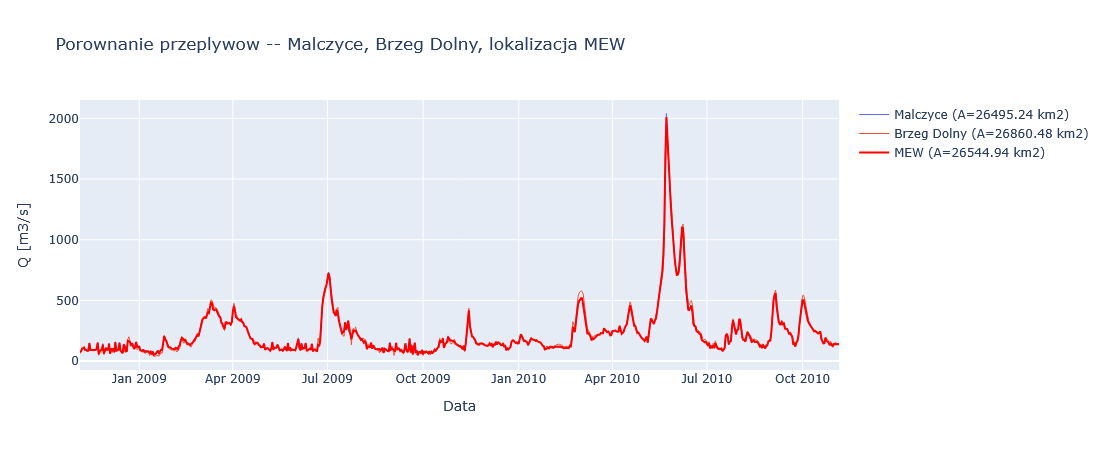

In [9]:
# Porownanie przeplywow -- ostatnie 2 lata
last_2y = df_mew[df_mew['date'] >= df_mew['date'].max() - pd.Timedelta(days=730)]

fig = go.Figure()
fig.add_trace(go.Scatter(x=last_2y['date'], y=last_2y['Q_up'],
    mode='lines', name=f'Malczyce (A={A_UP} km2)', line=dict(width=1)))
fig.add_trace(go.Scatter(x=last_2y['date'], y=last_2y['Q_down'],
    mode='lines', name=f'Brzeg Dolny (A={A_DOWN} km2)', line=dict(width=1)))
fig.add_trace(go.Scatter(x=last_2y['date'], y=last_2y['Q_mew'],
    mode='lines', name=f'MEW (A={A_TARGET} km2)', line=dict(color='red', width=2)))
fig.update_layout(
    title='Porownanie przeplywow -- Malczyce, Brzeg Dolny, lokalizacja MEW',
    xaxis_title='Data', yaxis_title='Q [m3/s]', height=450, hovermode='x unified',
)
fig.show()

---
## Krok 2: Sredni rok uporzadkowany dla lokalizacji MEW

Budujemy sredni rok uporzadkowany z interpolowanych przeplywow Q_mew.

**Prompt do LLM:**
> *"Napisz kod ktory: (1) utworzy DataFrame z kolumnami station_id, date, discharge_m3s
> z interpolowanych przeplywow Q_mew (station_id = 'MEW'), (2) przefiltruje lata
> niekompletne, (3) obliczy sredni rok uporzadkowany, (4) narysuje wykres FDC
> (srednia + zakres min-max) dla lokalizacji MEW."*

**Uzyte moduly/funkcje:** `src.hydrology.filter_incomplete_years()`, `src.hydrology.average_sorted_year()`

Removing 2 incomplete years: [2007, 2010]
Sredni rok uporzadkowany z 2 lat
Q: 51.76 -- 543.84 m3/s


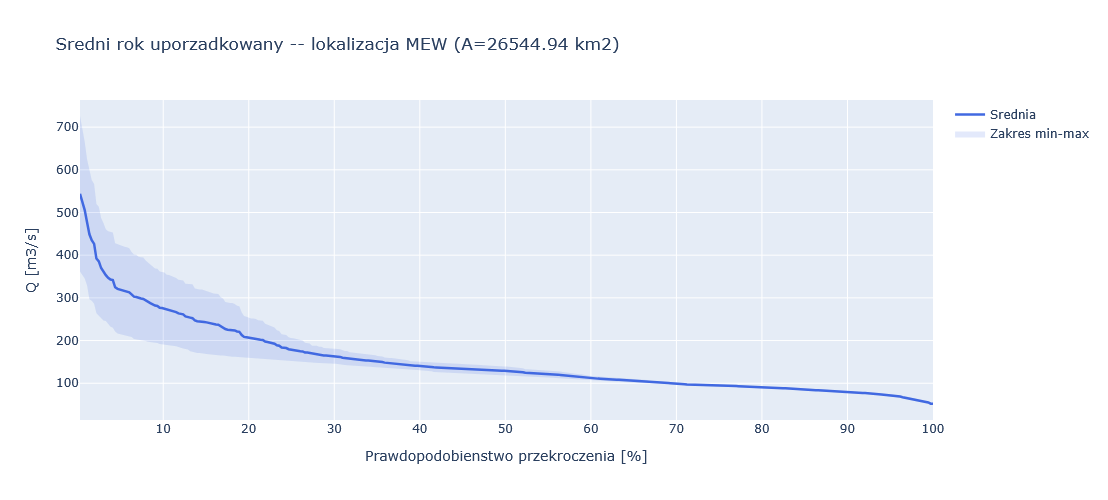

In [10]:
# Utworz DataFrame w formacie zgodnym z modulem hydrology
df_mew_hydro = pd.DataFrame({
    'station_id': 'MEW',
    'date': df_mew['date'],
    'discharge_m3s': df_mew['Q_mew'],
})

# Filtruj lata niekompletne i oblicz sredni rok uporzadkowany
df_mew_filt = filter_incomplete_years(df_mew_hydro, 'MEW', min_completeness=0.95)
avg_year = average_sorted_year(df_mew_filt, 'MEW')

print(f'Sredni rok uporzadkowany z {avg_year["n_years"].iloc[0]} lat')
print(f'Q: {avg_year["mean"].min():.2f} -- {avg_year["mean"].max():.2f} m3/s')

# Wykres FDC
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=avg_year['exceedance_pct'], y=avg_year['max'],
    mode='lines', line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(
    x=avg_year['exceedance_pct'], y=avg_year['min'],
    mode='lines', line=dict(width=0),
    fill='tonexty', fillcolor='rgba(65,105,225,0.15)', name='Zakres min-max'))
fig.add_trace(go.Scatter(
    x=avg_year['exceedance_pct'], y=avg_year['mean'],
    mode='lines', line=dict(color='royalblue', width=2.5), name='Srednia'))
fig.update_layout(
    title=f'Sredni rok uporzadkowany -- lokalizacja MEW (A={A_TARGET} km2)',
    xaxis_title='Prawdopodobienstwo przekroczenia [%]',
    yaxis_title='Q [m3/s]', height=500, hovermode='x unified',
)
fig.show()

---
## Krok 3: Parametry instalowane

Definiujemy parametry fizyczne i sprawnosci MEW:

| Parametr | Oznaczenie | Wartosc |
|----------|-----------|---------|
| Gestosc wody | rho | 998 kg/m3 |
| Przyspieszenie ziemskie | g | 9.81 m/s2 |
| Spad brutto | H_gross | 6 m |
| Sprawnosc turbiny | eta_t | 0.92 |
| Sprawnosc generatora | eta_g | 0.96 |
| Sprawnosc wlotu | eta_inlet | 0.98 |
| Sprawnosc wylotu | eta_outlet | 0.98 |
| Min. wspolczynnik przeplywu | Q_min_coeff | 0.15 (15% Q_design) |
| Min. wspolczynnik spadu | H_min_coeff | 0.50 (50% H_gross) |

**Prompt do LLM:**
> *"Napisz kod definiujacy parametry instalowane MEW jako slownik. Oblicz sprawnosc calkowita
> jako iloczyn wszystkich sprawnosci czastkowych. Wyswietl parametry."*

In [11]:
# Parametry instalowane
params = {
    'rho': 998,         # gestosc wody [kg/m3]
    'g': 9.81,          # przyspieszenie ziemskie [m/s2]
    'H_gross': 6.0,     # spad brutto [m]
    'eta_t': 0.92,      # sprawnosc turbiny [-]
    'eta_g': 0.96,      # sprawnosc generatora [-]
    'eta_inlet': 0.98,  # sprawnosc wlotu [-]
    'eta_outlet': 0.98, # sprawnosc wylotu [-]
    'Q_min_coeff': 0.15, # minimalny przeplyw (ulamek Q_design)
    'H_min_coeff': 0.50, # minimalny spad (ulamek H_gross)
}

# Sprawnosc calkowita
params['eta_total'] = (params['eta_t'] * params['eta_g']
                       * params['eta_inlet'] * params['eta_outlet'])

print('Parametry instalowane MEW:')
for k, v in params.items():
    print(f'  {k:15s} = {v}')
print(f'\nSprawnosc calkowita: eta_total = {params["eta_total"]:.6f}')

Parametry instalowane MEW:
  rho             = 998
  g               = 9.81
  H_gross         = 6.0
  eta_t           = 0.92
  eta_g           = 0.96
  eta_inlet       = 0.98
  eta_outlet      = 0.98
  Q_min_coeff     = 0.15
  H_min_coeff     = 0.5
  eta_total       = 0.84822528

Sprawnosc calkowita: eta_total = 0.848225


---
## Krok 4: Model spadu netto

Spad netto zalezy od stanu wody dolnej -- przy wiekszym przeplywu stan wody rosnie,
co zmniejsza spad uzytkowy.

**Podejscie uproszczone:** nie dysponujemy szczegolowa charakterystyka przekroju
poprzecznego koryta przy stopniu wodnym, dlatego zmiennosc poziomu wody dolnej
przyblizymy na podstawie zmian stanow wody na wodowskazie.

Mozliwe warianty:
- **jeden wodowskaz** (np. dolny -- Malczyce)
- **srednia z dwoch wodowskazow** (gorny i dolny)
- **interpolacja** miedzy wodowskazami (proporcjonalnie do zlewni)

Budujemy **sredni rok uporzadkowany** dla stanow wody (ta sama metoda co dla przeplywow),
a nastepnie:

$$H_{day} = H_{stage} + \overline{level} - level_{day}$$

gdzie:
- $H_{stage}$ -- spad brutto na stopniu [m]
- $\overline{level}$ -- sredni stan wody z wielolecia [m]
- $level_{day}$ -- stan wody w danym dniu sredniego roku uporzadkowanego [m]

Parowanie po ranku: najwyzszy przeplyw (ranga 1) odpowiada najwyzszemu stanowi wody
(najnizszy spad), najnizszy przeplyw (ranga 365) -- najnizszemu stanowi (najwyzszy spad).

**Prompt do LLM:**
> *"Napisz kod ktory: (1) obliczy sredni rok uporzadkowany dla stanow wody na wodowskazie
> dolnym (Malczyce) uzywajac average_sorted_year z column='water_level_cm',
> (2) obliczy sredni stan wody z wielolecia, (3) dla kazdego dnia (rangi) obliczy
> spad netto: H_day = H_stage + level_avg - level_day, (4) narysuje wykresy Q(t) i H(t)
> vs procent przekroczenia obok siebie."*

**Uzyte moduly/funkcje:** `src.hydrology.average_sorted_year(column='water_level_cm')`

In [ ]:
# Sredni rok uporzadkowany dla stanow wody (wodowskaz dolny -- Malczyce)
# Filtrujemy te same lata co dla przeplywu
df_down_filt = filter_incomplete_years(df, STATION_DOWN, min_completeness=0.95)
avg_level = average_sorted_year(df_down_filt, STATION_DOWN, column='water_level_cm')

# Sredni stan wody z wielolecia [m]
all_levels = df_down_filt.loc[
    df_down_filt['station_id'] == STATION_DOWN, 'water_level_cm'
].dropna().values / 100.0
level_avg = all_levels.mean()

# Sredni rok uporzadkowany stanow wody [m]
level_sorted = avg_level['mean'].values / 100.0  # cm -> m

print(f'Sredni rok uporzadkowany stanow wody z {avg_level["n_years"].iloc[0]} lat')
print(f'Sredni stan wody: {level_avg:.3f} m')
print(f'Zakres stanow (sr. rok): {level_sorted.min():.3f} -- {level_sorted.max():.3f} m')

# Spad netto: H_day = H_stage + level_avg - level_day
Q_sorted = avg_year['mean'].values
H_net = params['H_gross'] + (level_avg - level_sorted)
H_net = np.maximum(H_net, 0)

print(f'\nSpad netto: {H_net.min():.3f} -- {H_net.max():.3f} m')
print(f'Spad przy srednim stanie wody: {params["H_gross"]:.3f} m (= H_stage)')

In [ ]:
# Wykres: Q(t) i H(t) vs procent przekroczenia
fig = make_subplots(rows=1, cols=2,
    subplot_titles=['Przeplyw Q(t)', 'Spad netto H(t)'],
    horizontal_spacing=0.12)

pct = avg_year['exceedance_pct'].values

fig.add_trace(go.Scatter(x=pct, y=Q_sorted, mode='lines',
    line=dict(color='royalblue', width=2), name='Q'), row=1, col=1)
fig.add_trace(go.Scatter(x=pct, y=H_net, mode='lines',
    line=dict(color='firebrick', width=2), name='H'), row=1, col=2)

fig.update_xaxes(title_text='Prawdopodobienstwo przekroczenia [%]', row=1, col=1)
fig.update_xaxes(title_text='Prawdopodobienstwo przekroczenia [%]', row=1, col=2)
fig.update_yaxes(title_text='Q [m3/s]', row=1, col=1)
fig.update_yaxes(title_text='H [m]', row=1, col=2)
fig.update_layout(height=400, showlegend=False,
    title_text='Sredni rok uporzadkowany -- przeplyw i spad netto')
fig.show()

---
## Krok 5: Obliczenie mocy i energii dla wybranego punktu projektowego

### Punkt projektowy (na krzywej uporzadkowanej)

**Prawdopodobienstwo przekroczenia** $p$% oznacza, ze przeplyw $Q(p)$ jest
przekroczony (lub rowny) przez $p$% czasu w roku.

Punkt projektowy wyznacza **przeplyw projektowy turbiny** $Q_{design} = Q(p)$:

- $Q_{min} = c_{min} \cdot Q_{design}$ -- ponizej tego przeplywu turbina nie pracuje
- $Q_{wpp} = \min(Q_{available}, Q_{design})$ jesli $Q \geq Q_{min}$, inaczej 0
- $P = \rho \cdot g \cdot Q_{wpp} \cdot H_{netto} \cdot \eta_{total}$ [W]
- $E = \sum P \cdot 24h$ [kWh/rok]

Mniejszy procent przekroczenia = wieksza turbina = wieksza moc ale mniej dni pracy.
Wiekszy procent = mniejsza turbina = mniejsza moc ale wiecej dni pracy.
Optymalne jest gdzies **pomiedzy**.

**Prompt do LLM:**
> *"Napisz funkcje power_calculation(Q_sorted, H_net, rho, g, eta_total, install_day,
> Q_min_coeff, H_min_coeff) ktora: (1) wyznacza Q_design z Q_sorted[install_day-1],
> (2) oblicza Qmin i Hmin, (3) dla kazdego dnia oblicza Qwpp = min(Q, Q_design)
> jesli Q >= Qmin i H >= Hmin, inaczej 0, (4) oblicza moc P = rho*g*Qwpp*H*eta
> i energie E = P*24 [kWh], (5) zwraca DataFrame z kolumnami: day, Q, H, Q_design,
> Qwpp, P_kW, E_kWh. Nastepnie uzyj tej funkcji dla dnia instalacyjnego = 70
> i narysuj wykresy P(t) i skumulowanej E(t)."*

In [ ]:
def power_calculation(Q_sorted, H_net, rho, g, eta_total,
                      install_day, Q_min_coeff=0.15, H_min_coeff=0.5):
    """Oblicz moc i energie MEW dla danego dnia instalacyjnego.
    
    Args:
        Q_sorted: posortowane przeplywy (365 wartosci, malejaco)
        H_net: spad netto dla kazdego dnia (365 wartosci)
        rho: gestosc wody [kg/m3]
        g: przyspieszenie ziemskie [m/s2]
        eta_total: sprawnosc calkowita [-]
        install_day: dzien instalacyjny (1-365) na krzywej uporzadkowanej
        Q_min_coeff: minimalny przeplyw jako ulamek Q_design
        H_min_coeff: minimalny spad jako ulamek H_gross (max H)
    
    Returns:
        DataFrame z kolumnami: day, pct, Q, H, Q_design, Qwpp, P_kW, E_kWh
    """
    assert 1 <= install_day <= len(Q_sorted), f'install_day={install_day} poza zakresem'
    assert len(Q_sorted) == len(H_net), 'Q_sorted i H_net musza miec te sama dlugosc'
    
    n_days = len(Q_sorted)
    Q_design = Q_sorted[install_day - 1]
    Q_min = Q_min_coeff * Q_design
    H_min = H_min_coeff * H_net.max()
    
    # Wektoryzowane obliczenie
    mask = (Q_sorted >= Q_min) & (H_net >= H_min)
    Qwpp = np.where(mask, np.minimum(Q_sorted, Q_design), 0.0)
    
    P_kW = rho * g * Qwpp * H_net * eta_total / 1000  # W -> kW
    E_kWh = P_kW * 24  # kWh per day
    
    return pd.DataFrame({
        'day': np.arange(1, n_days + 1),
        'pct': np.round(np.arange(1, n_days + 1) / n_days * 100, 2),
        'Q': Q_sorted,
        'H': H_net,
        'Q_design': Q_design,
        'Qwpp': Qwpp,
        'P_kW': P_kW,
        'E_kWh': E_kWh,
    })

# Obliczenie dla dnia instalacyjnego = 70
INSTALL_DAY = 70
result = power_calculation(
    Q_sorted, H_net,
    params['rho'], params['g'], params['eta_total'],
    INSTALL_DAY, params['Q_min_coeff'], params['H_min_coeff'],
)

Q_design = result['Q_design'].iloc[0]
E_total_MWh = result['E_kWh'].sum() / 1000
P_max = result['P_kW'].max()
days_operating = (result['Qwpp'] > 0).sum()
install_pct = round(INSTALL_DAY / 365 * 100, 1)

print(f'Punkt projektowy: dzien {INSTALL_DAY} ({install_pct}% przekroczenia)')
print(f'Przeplyw projektowy Q_design = {Q_design:.2f} m3/s')
print(f'Qmin = {params["Q_min_coeff"] * Q_design:.2f} m3/s')
print(f'Moc maksymalna P_max = {P_max:.1f} kW')
print(f'Energia roczna E = {E_total_MWh:.1f} MWh/rok')
print(f'Dni pracy: {days_operating} / 365')

**Prompt do LLM:**
> *"Narysuj dwa wykresy: (1) moc MEW P(t) vs dzien roku z zaznaczonym Q_design i Qmin,
> (2) skumulowana energia E(t). Na wykresie mocy zaznacz strefami: pelna moc (Q > Q_design),
> czesciowa moc, i brak pracy (Q < Qmin)."*

In [ ]:
# Wykresy: moc i skumulowana energia vs procent przekroczenia
fig = make_subplots(rows=2, cols=1,
    subplot_titles=[
        f'Moc -- punkt projektowy {install_pct}% (Q_design = {Q_design:.1f} m3/s)',
        f'Skumulowana energia roczna -- E = {E_total_MWh:.0f} MWh/rok',
    ],
    vertical_spacing=0.15)

# Moc -- kolorowana wedlug stref pracy
colors = []
Q_min = params['Q_min_coeff'] * Q_design
for i in range(len(result)):
    if result['Qwpp'].iloc[i] == 0:
        colors.append('lightgray')
    elif result['Q'].iloc[i] >= Q_design:
        colors.append('green')
    else:
        colors.append('royalblue')

fig.add_trace(go.Bar(
    x=result['pct'], y=result['P_kW'],
    marker_color=colors, name='Moc [kW]', showlegend=False,
), row=1, col=1)

fig.add_hline(y=P_max, line_dash='dash', line_color='green',
    annotation_text=f'P_max = {P_max:.0f} kW', row=1, col=1)

# Skumulowana energia
E_cumsum = result['E_kWh'].cumsum() / 1000  # MWh
fig.add_trace(go.Scatter(
    x=result['pct'], y=E_cumsum,
    mode='lines', line=dict(color='firebrick', width=2),
    name='E skumulowana', showlegend=False,
), row=2, col=1)

fig.update_xaxes(title_text='Prawdopodobienstwo przekroczenia [%]', row=2, col=1)
fig.update_yaxes(title_text='P [kW]', row=1, col=1)
fig.update_yaxes(title_text='E [MWh]', row=2, col=1)
fig.update_layout(height=700, hovermode='x unified')
fig.show()

---
## Krok 6: Optymalizacja punktu projektowego

Iterujemy po roznych punktach na krzywej uporzadkowanej i dla kazdego obliczamy:
- przeplyw projektowy Q_design
- roczna energie E [MWh/rok]
- srednia moc P_avg [kW]

**Prawdopodobienstwo przekroczenia** p% oznacza, ze przeplyw jest przekroczony
przez p% czasu w roku. Np. punkt 20% = przeplyw przekroczony przez 73 dni/rok.

**Prompt do LLM:**
> *"Napisz kod ktory iteruje po dniach instalacyjnych od 10 do 350 (krok 1) i dla kazdego
> oblicza energie roczna uzywajac power_calculation(). Zbierz wyniki do DataFrame
> z kolumnami: install_day, Q_design, H_design, P_max_kW, E_MWh, days_operating.
> Znajdz optymalny dzien (max E). Narysuj wykres E vs dzien instalacyjny."*

In [ ]:
# Optymalizacja -- przeglad punktow projektowych
results_opt = []
for day in range(10, 351):
    r = power_calculation(
        Q_sorted, H_net,
        params['rho'], params['g'], params['eta_total'],
        day, params['Q_min_coeff'], params['H_min_coeff'],
    )
    results_opt.append({
        'install_day': day,
        'install_pct': round(day / 365 * 100, 1),
        'Q_design': r['Q_design'].iloc[0],
        'H_design': r['H'].iloc[day - 1],
        'P_max_kW': r['P_kW'].max(),
        'E_MWh': r['E_kWh'].sum() / 1000,
        'days_operating': (r['Qwpp'] > 0).sum(),
    })

df_opt = pd.DataFrame(results_opt)

# Optymalny punkt (max energia)
best = df_opt.loc[df_opt['E_MWh'].idxmax()]
print(f'Optymalny punkt: {best["install_pct"]:.0f}% przekroczenia (dzien {int(best["install_day"])})')
print(f'  Q_design = {best["Q_design"]:.2f} m3/s')
print(f'  P_max    = {best["P_max_kW"]:.1f} kW')
print(f'  E_roczna = {best["E_MWh"]:.1f} MWh/rok')
print(f'  Dni pracy: {int(best["days_operating"])} / 365')

In [ ]:
# Wykres: energia roczna i moc vs procent przekroczenia
fig = make_subplots(rows=2, cols=1,
    subplot_titles=['Energia roczna vs punkt projektowy',
                    'Moc maksymalna i dni pracy vs punkt projektowy'],
    vertical_spacing=0.15)

fig.add_trace(go.Scatter(
    x=df_opt['install_pct'], y=df_opt['E_MWh'],
    mode='lines', line=dict(color='firebrick', width=2), name='E [MWh/rok]',
), row=1, col=1)
fig.add_vline(x=best['install_pct'], line_dash='dash', line_color='black',
    annotation_text=f'Optimum: {best["install_pct"]:.0f}%', row=1, col=1)

fig.add_trace(go.Scatter(
    x=df_opt['install_pct'], y=df_opt['P_max_kW'],
    mode='lines', line=dict(color='green', width=2), name='P_max [kW]',
), row=2, col=1)
fig.add_trace(go.Scatter(
    x=df_opt['install_pct'], y=df_opt['days_operating'],
    mode='lines', line=dict(color='orange', width=2, dash='dot'), name='Dni pracy',
), row=2, col=1)

fig.update_xaxes(title_text='Prawdopodobienstwo przekroczenia [%]', row=2, col=1)
fig.update_yaxes(title_text='E [MWh/rok]', row=1, col=1)
fig.update_yaxes(title_text='P_max [kW] / Dni pracy', row=2, col=1)
fig.update_layout(height=700, hovermode='x unified')
fig.show()

---
## Krok 7: Analiza ekonomiczna

Uproszczony model ekonomiczny:
- **Koszt inwestycji** = koszt jednostkowy [EUR/kW] * moc zainstalowana P_max [kW] * kurs EUR/PLN
- **Koszty O&M** = 3% kosztow inwestycji rocznie (eksploatacja, utrzymanie)
- **Przychod roczny** = energia [MWh] * cena energii [PLN/MWh]
- **Okres zwrotu** = koszt inwestycji / (przychod - koszty O&M)

**Prompt do LLM:**
> *"Napisz kod analizy ekonomicznej: (1) zdefiniuj parametry ekonomiczne (cena energii
> 640 PLN/MWh, koszt jednostkowy 1300 EUR/kW mocy zainstalowanej, kurs EUR/PLN 4.6,
> koszty O&M 3% inwestycji rocznie), (2) dla kazdego dnia instalacyjnego z df_opt oblicz:
> koszt inwestycji (na bazie P_max), koszty O&M roczne, przychod roczny, zysk netto,
> okres zwrotu [lat], (3) znajdz dzien z najkrotszym okresem zwrotu,
> (4) narysuj wykresy: przychod i koszt vs dzien instalacyjny, okres zwrotu vs dzien."*

In [ ]:
# Parametry ekonomiczne
econ = {
    'energy_price': 640,     # cena energii [PLN/MWh]
    'cost_per_kw': 1300,     # koszt jednostkowy [EUR/kW mocy zainstalowanej]
    'eur_pln': 4.6,          # kurs EUR/PLN
    'om_fraction': 0.03,     # koszty O&M rocznie [% inwestycji]
}

# Obliczenia ekonomiczne dla kazdego punktu projektowego
df_econ = df_opt.copy()

# Koszt inwestycji na bazie mocy zainstalowanej (P_max)
unit_cost_pln = econ['cost_per_kw'] * econ['eur_pln']  # PLN/kW
df_econ['investment'] = unit_cost_pln * df_econ['P_max_kW']  # PLN

# Koszty O&M roczne
df_econ['om_annual'] = econ['om_fraction'] * df_econ['investment']

# Przychod roczny [PLN]
df_econ['income'] = df_econ['E_MWh'] * econ['energy_price']

# Zysk netto roczny
df_econ['net_income'] = df_econ['income'] - df_econ['om_annual']

# Okres zwrotu [lat]
df_econ['payback_years'] = df_econ['investment'] / df_econ['net_income']

# Najkrotszy okres zwrotu
best_econ = df_econ.loc[df_econ['payback_years'].idxmin()]
print(f'Najkrotszy okres zwrotu: {best_econ["install_pct"]:.0f}% przekroczenia')
print(f'  P_max        = {best_econ["P_max_kW"]:.0f} kW')
print(f'  E_roczna     = {best_econ["E_MWh"]:.0f} MWh/rok')
print(f'  Inwestycja   = {best_econ["investment"]/1e6:.2f} mln PLN')
print(f'  Przychod     = {best_econ["income"]/1e6:.2f} mln PLN/rok')
print(f'  Koszty O&M   = {best_econ["om_annual"]/1e6:.3f} mln PLN/rok')
print(f'  Okres zwrotu = {best_econ["payback_years"]:.1f} lat')

In [ ]:
# Wykresy ekonomiczne
fig = make_subplots(rows=2, cols=1,
    subplot_titles=['Przychod roczny i koszt inwestycji vs punkt projektowy',
                    'Okres zwrotu vs punkt projektowy'],
    vertical_spacing=0.15)

fig.add_trace(go.Scatter(
    x=df_econ['install_pct'], y=df_econ['income'] / 1e6,
    mode='lines', line=dict(color='green', width=2), name='Przychod [mln PLN/rok]',
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=df_econ['install_pct'], y=df_econ['investment'] / 1e6,
    mode='lines', line=dict(color='red', width=2), name='Inwestycja [mln PLN]',
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df_econ['install_pct'], y=df_econ['payback_years'],
    mode='lines', line=dict(color='royalblue', width=2), name='Okres zwrotu [lat]',
), row=2, col=1)
fig.add_vline(x=best_econ['install_pct'], line_dash='dash', line_color='black',
    annotation_text=f'Optimum: {best_econ["install_pct"]:.0f}% ({best_econ["payback_years"]:.1f} lat)')

fig.update_xaxes(title_text='Prawdopodobienstwo przekroczenia [%]', row=2, col=1)
fig.update_yaxes(title_text='[mln PLN]', row=1, col=1)
fig.update_yaxes(title_text='Okres zwrotu [lat]', row=2, col=1)
fig.update_layout(height=700, hovermode='x unified')
fig.show()

---
## Podsumowanie

W tym notebooku:
1. **Interpolacja** przeplywu do lokalizacji MEW miedzy Malczyce a Brzeg Dolny
2. **Sredni rok uporzadkowany** dla lokalizacji MEW (przeplyw i stan wody)
3. **Model spadu netto** -- H(Q) z uwzglednieniem zmian stanu wody dolnej
4. **Obliczenie mocy i energii** z ograniczeniami Qmin i Hmin
5. **Optymalizacja** dnia instalacyjnego -- maksymalizacja energii rocznej
6. **Analiza ekonomiczna** -- koszty, przychod, ROI, okres zwrotu

**Dalej:** dobor turbiny (typ, wymiary, predkosc obrotowa)